torch.Size([60000, 28, 28])
torch.Size([60000])
torch.Size([10000, 28, 28])
torch.Size([10000])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])


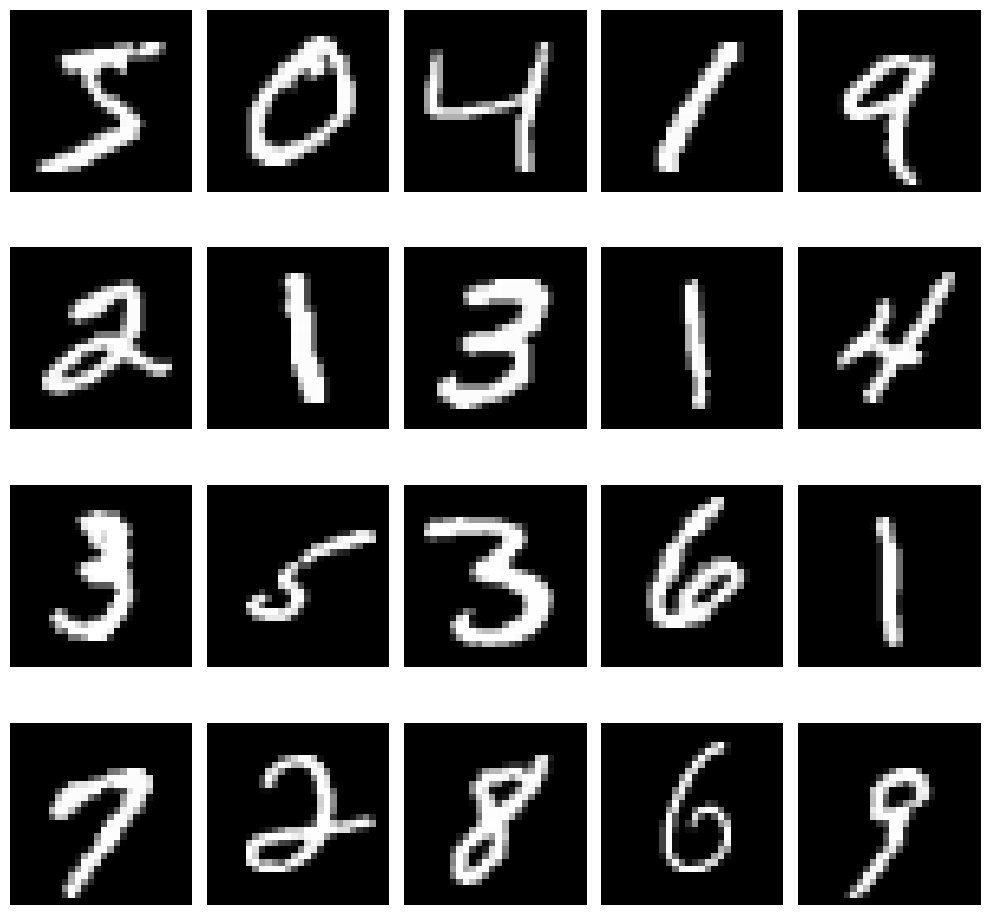

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt


# 定义组合转换，可以将多个转换操作作为一个整体执行。
transform = transforms.Compose([
    # 将图像数据转换为张量，并归一化到[0, 1]区间。
    transforms.ToTensor(),
    transforms.Normalize((0.1307, ), (0.3081, ))
])

# 获取MNIST数据集。
# root：数据集所在的根目录。
# train：是否获取训练集。
# download：root指定的目录没有数据时，是否下载数据。
# transform：对Mnist数据集进行的转换操作。
train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# 获取数据集底层张量数据（X）。
print(train_dataset.data.shape)
# 获取数据集底层张量数据（y）。
print(train_dataset.targets.shape)
print(test_dataset.data.shape)
print(test_dataset.targets.shape)
print(torch.unique(train_dataset.targets))
print(torch.bincount(train_dataset.targets))

# 图像可视化。
fig, ax = plt.subplots(4, 5, figsize=(10, 10))
ax = ax.ravel()
for i in range(20):
    ax[i].imshow(train_dataset.data[i], cmap="gray")
    ax[i].axis("off")
plt.tight_layout()

In [3]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        # x的形状为4维张量，shape=(batch_size, channels, height, width)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
epochs = 10
learning_rate = 0.01
# 当模型移动设备时，模型内部所有层的参数，会随着模型一起移动。
model = MnistModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
best_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        y_pred = output.argmax(dim=1)
        train_correct += y_pred.eq(target).sum().item()
    train_loss /= len(train_loader)
    train_accuracy = train_correct / len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    test_correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()
            y_pred = output.argmax(dim=1)
            test_correct += y_pred.eq(target).sum().item()
    test_loss /= len(test_loader)
    test_accuracy = test_correct / len(test_loader.dataset)

    print(f"Epoch {epoch + 1} / {epochs} "
        f"Train Loss:{train_loss:.4f} Train Accuracy: {train_accuracy:.4f} "
        f"Test Loss:{test_loss:.4f} Test Accuracy: {test_accuracy:.4f}")
    
    # 保存最佳模型（验证集损失最小的模型）。
    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), "model.pth")
        print("模型保存。")

Epoch 1 / 10 Train Loss:0.8630 Train Accuracy: 0.7729 Test Loss:0.3458 Test Accuracy: 0.8990
模型保存。


KeyboardInterrupt: 

In [4]:
from datasets import load_dataset


"""
通过Trainer训练模型，数据集要求如下：
* 数据集类型：
    + datasets.Dataset(Hugging Face的数据集对象)
    + torch.utils.data.Dataset(Python的数据集对象)
* 样本格式：
    + 每个样本需要是字典（dict）类型。
    + 字典key与模型前向传播（forward方法）中定义的参数名需要一致。
    + 至少包含模型需要的输入与标签。
"""

def preprocess_function(example, transform):
    """用于数据预处理的函数。

    Parameters
    ----------
    example : LazyRow or LazyBatch
        数据集中的一条（或一个批次）的数据。
    transform : torchvision.transforms.Compose
        数据预处理的转换操作。
    """
    # 对图像数据进行预处理。
    images = [transform(img) for img in example["image"]]
    return {
        "x": images
    }


def get_mnist_dataset():
    """获取mnist数据集。

    Returns
    -------
    dataset : datasets.Dataset
        mnist数据集。
    """
    # Hugging Face中，对于知名的数据集或模型，也可以直接通过简单名来访问。
    # 例如，mnist就会自动映射到ylecun/mnist。
    dataset = load_dataset("ylecun/mnist")
    # 标签名需要命名为labels。
    dataset = dataset.rename_column("label", "labels")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307, ), (0.3081, ))
    ])
    # 对数据集中的每个样本应用一个函数，生成一个新的数据集。
    # function：要应用的函数，该函数接收一个（批）样本（类似字典类型）作为输入。
    #   并返回一个（批）处理后的样本（字典类型）。
    #   返回的字典会与原始样本字典合并，键值对冲突时，返回字典会覆盖原始样本同名的key。
    # batched：是否按批次处理样本，默认为False。如果按批次处理样本，可以提高处理效率。
    # batch_size：一个批次的样本数量，默认为1000。
    # num_proc：指定要使用的进程数，可以多进程处理数据。
    # remove_columns：指定要从数据集中删除的列。可以清理不需要的列，减少内存占用。
    # transform：function函数的额外参数。
    dataset = dataset.map(
        function=preprocess_function,
        batched=True,
        batch_size=1000,
        num_proc=2,
        remove_columns=["image"],
        fn_kwargs={
            "transform": transform
        }
    )
    # map()仅负责将数据映射为Python对象，不会保留tensor类型。
    # 将数据集转换为指定的类型。
    # columns：设置需要转换类型的列。如果没有指定，则默认转换所有列。
    dataset.set_format("torch", columns=["x", "labels"])
    return dataset

dataset = get_mnist_dataset()
print(dataset)


ModuleNotFoundError: No module named 'datasets'